# **Data Analysis Example - Bitly & MovieLens**

### **13.1 Bitly Data from 1.USA.gov**

### **1. Thông tin tổng quan**
Bộ dữ liệu 1.USA.gov Bitly được thu thập vào năm 2011 thông qua sự hợp tác giữa dịch vụ rút gọn URL Bitly và trang web chính phủ Mỹ USA.gov.
Khi người dùng truy cập các liên kết rút gọn có đuôi .gov hoặc .mil, hệ thống Bitly sẽ tự động ghi nhận một số thông tin ẩn danh (không chứa dữ liệu cá nhân).

Dữ liệu được lưu dưới dạng tệp văn bản, trong đó mỗi dòng là một đối tượng JSON. Bộ dữ liệu này thường được sử dụng trong các ví dụ phân tích dữ liệu thực hành vì:

- Nó phản ánh hành vi truy cập thực tế của người dùng trên Internet,

- Có cấu trúc đơn giản nhưng đa dạng biến,

- Dễ xử lý bằng Python và các thư viện như pandas, numpy.

Ý nghĩa của các biến
| Tên biến                    | Kiểu dữ liệu      | Ý nghĩa                                                                                                                                                | Ví dụ                                                    |
| --------------------------- | ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ | -------------------------------------------------------- |
| `a` (User-Agent)            | *string*          | Thông tin về trình duyệt và hệ điều hành của người dùng truy cập liên kết. Dữ liệu này giúp phân loại người dùng theo nền tảng (Windows, Mac, Linux…). | `"Mozilla/5.0 (Windows NT 6.1; WOW64)"`                  |
| `tz` (Time Zone)            | *string* / *null* | Múi giờ địa lý mà người dùng truy cập (theo chuẩn IANA). Dữ liệu này hỗ trợ phân tích vị trí địa lý và thời điểm hoạt động.                            | `"America/New_York"`, `"Europe/London"`, `""`, `null`    |
| `r` (Referrer)              | *string*          | URL nguồn mà người dùng click để đến liên kết rút gọn. Giúp xác định kênh giới thiệu.                                                                  | `"http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf"` |
| `u` (Target URL)            | *string*          | URL gốc mà liên kết rút gọn trỏ đến.                                                                                                                   | `"http://www.ncbi.nlm.nih.gov/pubmed/22415991"`          |
| `c` (Country Code)          | *string*          | Mã quốc gia của người truy cập (theo chuẩn ISO).                                                                                                       | `"US"`                                                   |
| `cy` (City)                 | *string*          | Tên thành phố truy cập.                                                                                                                                | `"Danvers"`                                              |
| `gr` (State/Region Code)    | *string*          | Mã tiểu bang hoặc vùng của người dùng.                                                                                                                 | `"MA"`                                                   |
| `ll` (Latitude & Longitude) | *array of float*  | Tọa độ địa lý (vĩ độ, kinh độ) của người dùng truy cập.                                                                                                | `[42.576698, -70.954903]`                                |
| `nk` (Click Count)          | *int*             | Số lượt click vào liên kết.                                                                                                                            | `1`                                                      |
| `t` (Timestamp)             | *int*             | Thời gian truy cập tính theo Unix timestamp.                                                                                                           | `1331923247`                                             |
| `hc` (Hash Created Time)    | *int*             | Thời điểm liên kết được tạo (Unix timestamp).                                                                                                          | `1331822918`                                             |
| `hh` (Short Domain)         | *string*          | Tên miền rút gọn, thường là `1.usa.gov`.                                                                                                               | `"1.usa.gov"`                                            |
| `g` / `h` / `l`             | *string*          | Các mã hash nội bộ Bitly — giúp định danh liên kết.                                                                                                    | `"A6qOVH"`, `"wfLQtf"`, `"orofrog"`                      |


### **2. Tìm hiểu dữ liệu**

In [3]:
import json
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
path = "C:/Users/Admin/OneDrive/Documents/lab02/dataset/example.txt"
with open(path) as f:
    print(f.read())

{ "a": "Mozilla\/5.0 (Windows NT 6.1; WOW64) AppleWebKit\/535.11 (KHTML, like Gecko) Chrome\/17.0.963.78 Safari\/535.11", "c": "US", "nk": 1, "tz": "America\/New_York", "gr": "MA", "g": "A6qOVH", "h": "wfLQtf", "l": "orofrog", "al": "en-US,en;q=0.8", "hh": "1.usa.gov", "r": "http:\/\/www.facebook.com\/l\/7AQEFzjSi\/1.usa.gov\/wfLQtf", "u": "http:\/\/www.ncbi.nlm.nih.gov\/pubmed\/22415991", "t": 1331923247, "hc": 1331822918, "cy": "Danvers", "ll": [ 42.576698, -70.954903 ] }
{ "a": "GoogleMaps\/RochesterNY", "c": "US", "nk": 0, "tz": "America\/Denver", "gr": "UT", "g": "mwszkS", "h": "mwszkS", "l": "bitly", "hh": "j.mp", "r": "http:\/\/www.AwareMap.com\/", "u": "http:\/\/www.monroecounty.gov\/etc\/911\/rss.php", "t": 1331923249, "hc": 1308262393, "cy": "Provo", "ll": [ 40.218102, -111.613297 ] }
{ "a": "Mozilla\/4.0 (compatible; MSIE 8.0; Windows NT 6.1; WOW64; Trident\/4.0; SLCC2; .NET CLR 2.0.50727; .NET CLR 3.5.30729; .NET CLR 3.0.30729; Media Center PC 6.0; .NET4.0C; .NET4.0E; InfoP

##### **Nhận xét**
- Đây là log truy cập các liên kết rút gọn từ 1.usa.gov.

- Mỗi dòng là một bản ghi JSON, chứa thông tin chi tiết về người dùng và lượt truy cập.

- Các trường phổ biến:

- a: thông tin trình duyệt

- c: quốc gia

- tz: múi giờ

- cy: thành phố

- ll: tọa độ địa lý

- r: nguồn truy cập (referrer)

- u: link đích thật sự

- Có cả giá trị thiếu (null hoặc ""), và bản ghi đặc biệt như "_heartbeat_" dùng để kiểm tra kết nối.

- Phù hợp cho các bài tập tiền xử lý dữ liệu, phân tích thống kê, visualization (ví dụ đếm truy cập theo múi giờ, quốc gia, trình duyệt…).

In [5]:
with open(path) as f:
 records = [json.loads(line) for line in f]
records[0]

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

##### **Nhận xét**
- Người dùng truy cập từ Mỹ (US), thành phố Danvers, bang MA, múi giờ America/New_York.

- Sử dụng trình duyệt Chrome trên Windows.

- Nguồn truy cập từ Facebook, dẫn tới trang NCBI.

- Có đầy đủ thông tin ngôn ngữ, thời gian, vị trí và URL → bản ghi này rất đầy đủ, có thể dùng tốt cho phân tích thống kê.

#### **3. Trích xuất & xử lý dữ liệu**

In [6]:
time_zones = [rec["tz"] for rec in records if "tz" in rec]
time_zones[:10]

['America/New_York',
 'America/Denver',
 'America/New_York',
 'America/Sao_Paulo',
 'America/New_York',
 'America/New_York',
 'Europe/Warsaw',
 '',
 '',
 '']

##### **Nhận xét**
- Phần lớn người dùng truy cập từ America/New_York.

- Có 1 người từ Nam Mỹ (Sao_Paulo) và 1 từ châu Âu (Warsaw).

- Nhiều giá trị bị thiếu (''), cần xử lý trước khi phân tích thống kê.

In [7]:
def get_counts(sequence):
    counts = {}
    for x in sequence:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1
    return counts

In [8]:
from collections import defaultdict
def get_counts2(sequence):
    counts = defaultdict(int) # values will initialize to 0
    for x in sequence:
        counts[x] += 1
    return counts

In [9]:
counts = get_counts(time_zones)
counts["America/New_York"]
len(time_zones)

3440

In [10]:
def top_counts(count_dict, n=10):
    value_key_pairs = [(count, tz) for tz, count in count_dict.items()]
    value_key_pairs.sort()
    return value_key_pairs[-n:]
top_counts(counts)

[(33, 'America/Sao_Paulo'),
 (35, 'Europe/Madrid'),
 (36, 'Pacific/Honolulu'),
 (37, 'Asia/Tokyo'),
 (74, 'Europe/London'),
 (191, 'America/Denver'),
 (382, 'America/Los_Angeles'),
 (400, 'America/Chicago'),
 (521, ''),
 (1251, 'America/New_York')]

##### **Nhận xét**
- Dữ liệu cho thấy múi giờ có lượng truy cập cao nhất là America/New_York (1251). 
- Tiếp theo là America/Chicago (400) và America/Los_Angeles (382). Một số múi giờ khác có lượng truy cập thấp hơn đáng kể.
- Đáng chú ý có 521 truy cập không xác định múi giờ, cần được xử lý hoặc làm sạch dữ liệu.

In [11]:
from collections import Counter
counts = Counter(time_zones)
counts.most_common(10)

[('America/New_York', 1251),
 ('', 521),
 ('America/Chicago', 400),
 ('America/Los_Angeles', 382),
 ('America/Denver', 191),
 ('Europe/London', 74),
 ('Asia/Tokyo', 37),
 ('Pacific/Honolulu', 36),
 ('Europe/Madrid', 35),
 ('America/Sao_Paulo', 33)]

##### **Nhận xét**
- Lượt truy cập tập trung chủ yếu ở America/New_York, phần còn lại thấp hơn nhiều. Có 521 lượt không xác định múi giờ.

#### **4. Trực quan hoá dữ liệu**

In [12]:
frame = pd.DataFrame(records)

In [13]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   object 
 1   c            2919 non-null   object 
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   object 
 4   gr           2919 non-null   object 
 5   g            3440 non-null   object 
 6   h            3440 non-null   object 
 7   l            3440 non-null   object 
 8   al           3094 non-null   object 
 9   hh           3440 non-null   object 
 10  r            3440 non-null   object 
 11  u            3440 non-null   object 
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   object 
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     object 
dtypes: float64(4), object(14)
memory usage: 500.8+ K

##### **Nhận xét**
- DataFrame có 3560 dòng và 18 cột, gồm cả kiểu object và float64. Một số cột có giá trị khuyết nhiều như _heartbeat_ (120 giá trị) và kw (93 giá trị), cần được xử lý.
- Các cột còn lại như a, tz, g… có số giá trị không khuyết cao, phù hợp cho phân tích chính.

In [14]:
frame["tz"].head()

0     America/New_York
1       America/Denver
2     America/New_York
3    America/Sao_Paulo
4     America/New_York
Name: tz, dtype: object

##### **Nhận xét**
- Cột tz chứa tên múi giờ, chủ yếu là America/New_York, cùng một số múi giờ khác như America/Denver và America/Sao_Paulo. Đây là dữ liệu phân loại (categorical).

In [15]:
tz_counts = frame["tz"].value_counts()
tz_counts.head()

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

##### **Nhận xét**
- Phần lớn lượt truy cập thuộc America/New_York (1251), tiếp theo là Chicago (400), Los_Angeles (382), Denver (191). Có 521 lượt không xác định múi giờ.

In [16]:
clean_tz = frame["tz"].fillna("Missing")
clean_tz[clean_tz == ""] = "Unknown"
tz_counts = clean_tz.value_counts()
tz_counts.head()

tz
America/New_York       1251
Unknown                 521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

##### **Nhận xét**
- Lượt truy cập chủ yếu từ America/New_York (1251). Các múi giờ khác ít hơn, và có 521 lượt Unknown cần xử lý.

<Axes: ylabel='tz'>

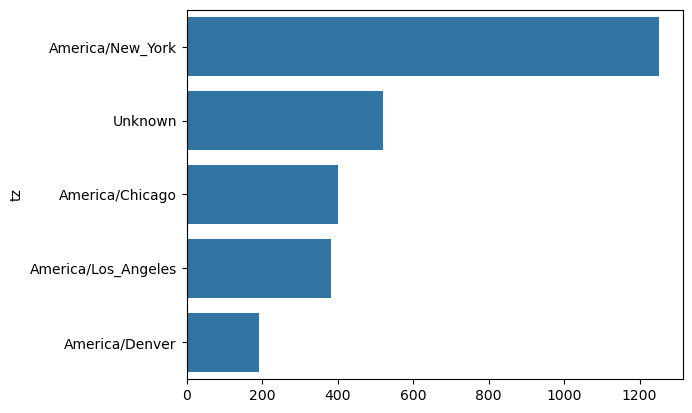

In [17]:
import seaborn as sns
subset = tz_counts.head()
sns.barplot(y=subset.index, x=subset.to_numpy())

##### **Nhận xét**
- Biểu đồ cho thấy múi giờ America/New_York chiếm tỷ lệ lớn nhất, trong khi các múi giờ khác như Chicago, Los_Angeles, và Denver có số lượng thấp hơn.
- Ngoài ra, nhóm Unknown chiếm tỷ lệ khá đáng kể, cho thấy còn dữ liệu chưa xác định múi giờ.

#### **5. Phân tích nâng cao với Pandas**

In [18]:
frame["a"][1]

'GoogleMaps/RochesterNY'

##### **Nhận xét**
- Đây có vẻ là giá trị của cột vị trí hoặc nguồn truy cập, chỉ rõ Google Maps tại Rochester, NY. Có thể dùng để phân tích theo vị trí địa lý cụ thể.

In [ ]:
frame["a"][50]

'Mozilla/5.0 (Windows NT 5.1; rv:10.0.2) Gecko/20100101 Firefox/10.0.2'

##### **Nhận xét**
Đây là user agent của trình duyệt, cho biết:

- Trình duyệt: Firefox 10.0.2

- Hệ điều hành: Windows XP (NT 5.1)

- Engine: Gecko

Dùng để phân tích thiết bị, trình duyệt, OS của người dùng.

In [ ]:
frame["a"][51][:50]

'Mozilla/5.0 (Linux; U; Android 2.2.2; en-us; LG-P9'

##### **Nhận xét**
Đây là user agent của thiết bị di động, cho biết:

- Hệ điều hành: Android 2.2.2

- Ngôn ngữ: en-us

- Thiết bị: LG-P9

- Trình duyệt: chưa đầy đủ thông tin, thường kèm theo engine/phiên bản browser.

Có thể dùng để phân tích thiết bị và OS di động của người dùng.

In [ ]:
results = pd.Series([x.split()[0] for x in frame["a"].dropna()])
results.head(5)

0               Mozilla/5.0
1    GoogleMaps/RochesterNY
2               Mozilla/4.0
3               Mozilla/5.0
4               Mozilla/5.0
dtype: object

##### **Nhận xét**
Cột này chứa thông tin user agent hoặc nguồn truy cập, bao gồm:

- Trình duyệt phổ biến: Mozilla/5.0, Mozilla/4.0

- Ứng dụng/địa điểm: GoogleMaps/RochesterNY

Có thể dùng để phân loại trình duyệt, thiết bị, hoặc nguồn truy cập.

In [ ]:
results.value_counts().head(8)

Mozilla/5.0                 2594
Mozilla/4.0                  601
GoogleMaps/RochesterNY       121
Opera/9.80                    34
TEST_INTERNET_AGENT           24
GoogleProducer                21
Mozilla/6.0                    5
BlackBerry8520/5.0.0.681       4
Name: count, dtype: int64

##### **Nhận xét**
- Phần lớn truy cập đến từ Mozilla/5.0 (2594), tiếp theo là Mozilla/4.0 (601).
- Một số nguồn khác như GoogleMaps/RochesterNY (121) và Opera/9.80 (34) ít hơn.
- Các user agent hiếm hoặc thử nghiệm như TEST_INTERNET_AGENT, GoogleProducer, Mozilla/6.0, BlackBerry chiếm rất ít.

In [ ]:
cframe = frame[frame["a"].notna()].copy()
cframe["os"] = np.where(cframe["a"].str.contains("Windows"),"Windows", "Not Windows")
cframe["os"].head(5)

0        Windows
1    Not Windows
2        Windows
3    Not Windows
4        Windows
Name: os, dtype: object

##### **Nhận xét**
- Cột os phân loại hệ điều hành thành Windows và Not Windows, giúp tách người dùng theo hệ điều hành chính.

In [ ]:
by_tz_os = cframe.groupby(["tz", "os"])

In [ ]:
agg_counts = by_tz_os.size().unstack().fillna(0)
agg_counts.head()

os,Not Windows,Windows
tz,,
,245.0,276.0
Africa/Cairo,0.0,3.0
Africa/Casablanca,0.0,1.0
Africa/Ceuta,0.0,2.0
Africa/Johannesburg,0.0,1.0


##### **Nhận xét**
Bảng cho thấy số lượng truy cập phân theo múi giờ (tz) và hệ điều hành (os). Ví dụ:

- Africa/Cairo: 3 truy cập từ Windows, 0 từ Not Windows

- Africa/Casablanca: 1 truy cập từ Windows

- Africa/Ceuta: 2 truy cập từ Windows

Hầu hết các truy cập tại các múi giờ này đều từ Windows, trong khi giá trị 245.0 (có thể là Unknown) có 276 truy cập Not Windows.

#### **6. Trực quan hoá theo hệ điều hành**

In [105]:
indexer = agg_counts.sum("columns").argsort()
indexer.values[:10]

array([ 2,  7,  5,  4, 14, 11,  9,  8, 24, 26])

##### **Nhận xét**
- Đây là một mảng số nguyên gồm 10 phần tử: [2, 7, 5, 4, 14, 11, 9, 8, 24, 26]. Có thể dùng để phân tích, tính toán thống kê hoặc lập biểu đồ.

In [106]:
count_subset = agg_counts.take(indexer[-10:])
count_subset

os,Not Windows,Windows
tz,,
America/Sao_Paulo,13.0,20.0
Europe/Madrid,16.0,19.0
Pacific/Honolulu,0.0,36.0
Asia/Tokyo,2.0,35.0
Europe/London,43.0,31.0
America/Denver,132.0,59.0
America/Los_Angeles,130.0,252.0
America/Chicago,115.0,285.0
,245.0,276.0


##### **Nhận xét**
Bảng cho thấy lượt truy cập phân theo múi giờ và hệ điều hành:

- America/New_York chiếm cao nhất, chủ yếu từ Windows (912).

- Los_Angeles và Chicago cũng nhiều lượt, tập trung từ Windows.

- Europe/London và Denver có lượng Not Windows đáng kể.

- Một số múi giờ nhỏ như Tokyo, Honolulu, Sao_Paulo, Madrid ít lượt hơn.

- Giá trị 245.0 có thể là Unknown, chủ yếu từ Not Windows.

Nhìn chung, Windows chiếm ưu thế ở hầu hết múi giờ, ngoại trừ các trường hợp Unknown hoặc London/Denver.

In [107]:
agg_counts.sum(axis="columns").nlargest(10)

tz
America/New_York       1251.0
                        521.0
America/Chicago         400.0
America/Los_Angeles     382.0
America/Denver          191.0
Europe/London            74.0
Asia/Tokyo               37.0
Pacific/Honolulu         36.0
Europe/Madrid            35.0
America/Sao_Paulo        33.0
dtype: float64

##### **Nhận xét**
- Lượt truy cập tập trung chủ yếu ở America/New_York (1251), tiếp theo là Chicago (400) và Los_Angeles (382).
- Có 521 lượt không xác định múi giờ, các múi giờ khác ít hơn đáng kể.

In [108]:
count_subset = count_subset.stack()
count_subset.name = "total"
count_subset = count_subset.reset_index()
count_subset.head(10)

,tz,os,total
0,America/Sao_Paulo,Not Windows,13.0
1,America/Sao_Paulo,Windows,20.0
2,Europe/Madrid,Not Windows,16.0
3,Europe/Madrid,Windows,19.0
4,Pacific/Honolulu,Not Windows,0.0
5,Pacific/Honolulu,Windows,36.0
6,Asia/Tokyo,Not Windows,2.0
7,Asia/Tokyo,Windows,35.0
8,Europe/London,Not Windows,43.0
9,Europe/London,Windows,31.0


##### **Nhận xét**
Bảng này thể hiện số lượt truy cập theo múi giờ (tz) và hệ điều hành (os).

- Ví dụ: America/Sao_Paulo có 20 truy cập từ Windows, 13 từ Not Windows.

- Europe/London có lượng Not Windows cao hơn Windows (43 so với 31).

- Các múi giờ khác như Honolulu và Tokyo chủ yếu từ Windows.

Có thể dùng bảng này để so sánh phổ hệ điều hành theo khu vực.

<Axes: xlabel='total', ylabel='tz'>

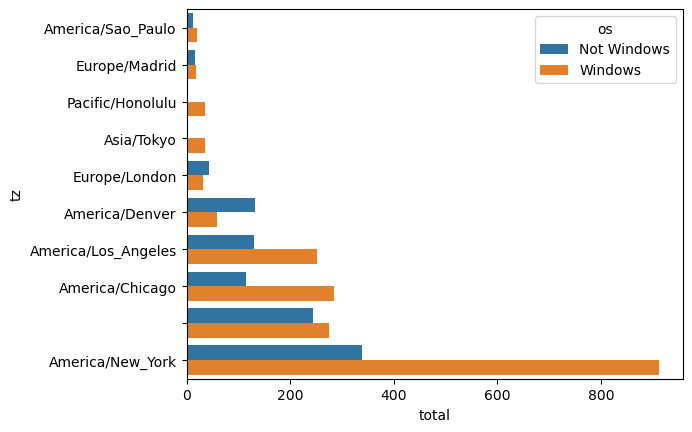

In [109]:
sns.barplot(x="total", y="tz", hue="os",  data=count_subset)

##### **Nhận xét**
- Biểu đồ cho thấy người dùng hệ điều hành Windows chiếm ưu thế ở hầu hết các múi giờ, đặc biệt là tại America/New_York, nơi có số lượng vượt trội so với các nhóm khác.
- Trong khi đó, Not Windows có mặt ở hầu hết múi giờ nhưng với số lượng thấp hơn.
- Một số khu vực như Europe/London, Asia/Tokyo, hay Pacific/Honolulu có số lượng người dùng rất ít.

In [114]:
def norm_total(group):
    group["normed_total"] = group["total"] / group["total"].sum()
    return group
results = count_subset.groupby("tz").apply(norm_total)

C:\Users\Admin\AppData\Local\Temp\ipykernel_9840\2692722749.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results = count_subset.groupby("tz").apply(norm_total)


<Axes: xlabel='normed_total', ylabel='tz'>

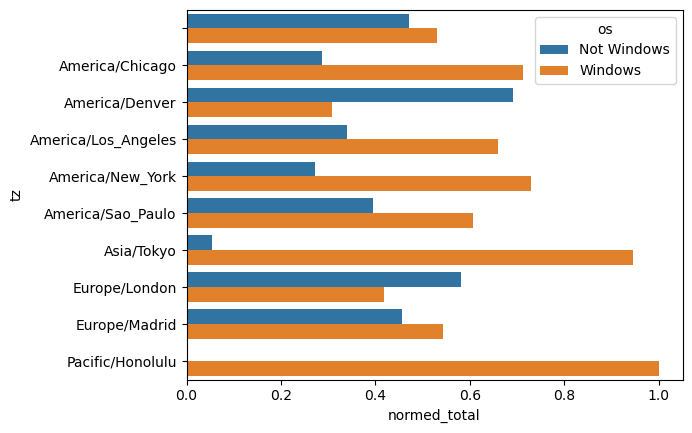

In [113]:
sns.barplot(x="normed_total", y="tz", hue="os",  data=results)

##### **Nhận xét**
- Biểu đồ cho thấy hệ điều hành Windows chiếm ưu thế ở hầu hết các múi giờ, đặc biệt nổi bật tại Pacific/Honolulu và Asia/Tokyo.
- Trong khi đó, Not Windows có tỷ lệ cao hơn tại America/Denver và Europe/London, cho thấy sự phân bố hệ điều hành khác nhau tùy theo khu vực địa lý.

In [115]:
g = count_subset.groupby("tz")
results2 = count_subset["total"] / g["total"].transform("sum")

### **13.2. MovieLens 1M Dataset**

### **1. Thông tin tổng quan**
MovieLens 1M là một bộ dữ liệu chuẩn mực ổn định (stable benchmark dataset) thường được sử dụng trong nghiên cứu về hệ thống gợi (recommendation systems) và khai phá dữ liệu.

Nguồn gốc: Được thu thập bởi nhóm nghiên cứu GroupLens tại Đại học Minnesota, Mỹ.

Quy mô: Chứa hơn 1 triệu đánh giá (rating) từ 6.040 người dùng về 3.900 bộ phim.

Mục đích: Nghiên cứu và phát triển các thuật toán gợi ý phim, phân tích hành vi và sở thích của người dùng, đặc biệt là sự khác biệt trong đánh giá giữa các nhóm người dùng khác nhau (như Giới tính).

Bộ dữ liệu được chia thành ba tệp chính, được liên kết với nhau bằng các ID chung (user_id và movie_id):
| **Tệp dữ liệu** | **Nội dung chính**                                                                                                      | **Biến liên kết**     |
| --------------- | ----------------------------------------------------------------------------------------------------------------------- | --------------------- |
| `ratings.dat`   | Chứa 1 triệu bản ghi về điểm đánh giá (rating) và thời điểm đánh giá (timestamp).                                       | `user_id`, `movie_id` |
| `users.dat`     | Chứa thông tin nhân khẩu học của 6.040 người dùng, bao gồm gender (giới tính), age (tuổi), và occupation (nghề nghiệp). | `user_id`             |
| `movies.dat`    | Chứa thông tin về 3.900 bộ phim, bao gồm title (tiêu đề) và genres (thể loại).                                          | `movie_id`            |


Ý nghĩa của các biến

**users.dat**
| **Tên biến** | **Ý nghĩa**   | **Giá trị**                                                                                                  |
| ------------ | ------------- | ------------------------------------------------------------------------------------------------------------ |
| `user_id`    | Mã Người dùng | Mã định danh duy nhất cho mỗi người dùng                                                                     |
| `gender`     | Giới tính     | `'F'` (Nữ) hoặc `'M'` (Nam)                                                                                  |
| `age`        | Tuổi          | Được mã hóa thành các nhóm tuổi (ví dụ: `1`: Under 18, `25`: 25–34, `56`: 56+)                               |
| `occupation` | Nghề nghiệp   | Mã số đại diện cho 21 loại nghề nghiệp khác nhau (ví dụ: `0`: other, `1`: academic/educator, `4`: artist, …) |
| `zip`        | Zip-code      | Mã bưu chính của người dùng (ít được sử dụng trong phân tích cơ bản)                                         |

**ratings.dat**
| **Tên biến** | **Ý nghĩa**   | **Giá trị**                                                                                               |
| ------------ | ------------- | --------------------------------------------------------------------------------------------------------- |
| `user_id`    | Mã Người dùng | Liên kết với tệp `users.dat`                                                                              |
| `movie_id`   | Mã Phim       | Liên kết với tệp `movies.dat`                                                                             |
| `rating`     | Điểm Đánh giá | Điểm số từ `1` (thấp nhất) đến `5` (cao nhất). Đây là biến đo lường chính để phân tích sự không đồng tình |
| `timestamp`  | Dấu thời gian | Thời gian đánh giá được tạo, lưu dưới dạng số giây từ Epoch (Unix time)                                   |

**movies.dat**
| **Tên biến** | **Ý nghĩa**  | **Ghi chú**                                                              |     |
| ------------ | ------------ | ------------------------------------------------------------------------ | --- |
| `movie_id`   | Mã Phim      | Mã định danh duy nhất cho mỗi bộ phim.                                   |     |
| `title`      | Tiêu đề Phim | Tên đầy đủ của bộ phim, thường bao gồm năm phát hành.                    |     |
| `genres`     | Thể loại     | Một chuỗi chứa nhiều thể loại phim, được phân tách bằng dấu gạch đứng (` | `). |


### **2. Tìm hiểu dữ liệu**

In [48]:
import pandas as pd
import numpy as np
import os

In [116]:
# Đường dẫn đến các tệp dữ liệu MovieLens 1M
data_dir = "C:/Users/Admin/OneDrive/Documents/lab02/dataset/ml-1m/ml-1m/"
# Định nghĩa tên cột và đọc tệp (giữ nguyên theo sách)
unames = ['user_id', 'gender', 'age', 'occupation', 'zip']
rnames = ['user_id', 'movie_id', 'rating', 'timestamp']
mnames = ['movie_id', 'title', 'genres']

# Đọc tệp, sử dụng '::' làm dấu phân cách
users = pd.read_table(os.path.join(data_dir + "users.dat"), sep="::", header=None, names=unames, engine='python')
ratings = pd.read_table(os.path.join(data_dir + "ratings.dat"), sep="::", header=None, names=rnames, engine='python')
movies = pd.read_table(os.path.join(data_dir + "movies.dat"), sep="::", header=None, names=mnames, engine='python', encoding='latin-1')

In [51]:
users.head(5)

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


##### **Nhận xét**
Đây là một DataFrame người dùng với các cột:

- user_id: ID người dùng

- gender: Giới tính (F/M)

- age: Tuổi

- occupation: Mã nghề nghiệp

- zip: Mã bưu điện

Dữ liệu cho phép phân tích nhân khẩu học và nghề nghiệp của người dùng

In [52]:
ratings.head(5)

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


##### **Nhận xét**
Đây là một DataFrame đánh giá phim với các cột:

- user_id: ID người dùng

- movie_id: ID phim

- rating: điểm đánh giá (thường từ 1–5)

- timestamp: thời gian đánh giá (dạng Unix timestamp)

Dữ liệu này dùng để phân tích sở thích người dùng, xây dựng hệ thống gợi ý phim.

In [53]:
movies.head(5)

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


##### **Nhận xét**
Đây là một DataFrame thông tin phim với các cột:

- movie_id: ID phim

- title: Tên phim kèm năm sản xuất

- genres: Thể loại phim, nhiều thể loại được phân tách bằng |

Dữ liệu này dùng để liên kết với đánh giá người dùng và phân tích theo thể loại phim.

In [54]:
ratings

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


##### **Nhận xét**

Đây là DataFrame lớn về đánh giá phim với 1.000.209 dòng và 4 cột:

- user_id: ID người dùng

- movie_id: ID phim

- rating: điểm đánh giá (1–5)

- timestamp: thời gian đánh giá (Unix timestamp)

Dữ liệu này phù hợp để phân tích hành vi người dùng, xu hướng phim, hoặc xây dựng hệ thống gợi ý phim (recommender system).

### **3. Gộp bảng dữ liệu**

In [55]:
data = pd.merge(pd.merge(ratings, users), movies)
data

,user_id,movie_id,rating,timestamp,gender,age,occupation,zip,title,genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy
...,...,...,...,...,...,...,...,...,...,...
1000204,6040,1091,1,956716541,M,25,6,11106,Weekend at Bernie's (1989),Comedy
1000205,6040,1094,5,956704887,M,25,6,11106,"Crying Game, The (1992)",Drama|Romance|War
1000206,6040,562,5,956704746,M,25,6,11106,Welcome to the Dollhouse (1995),Comedy|Drama
1000207,6040,1096,4,956715648,M,25,6,11106,Sophie's Choice (1982),Drama


##### **Nhận xét**
Bạn vừa hợp nhất thông tin đánh giá phim, người dùng và phim thành một DataFrame 10 cột, 1.000.209 dòng:

- user_id, gender, age, occupation, zip → thông tin người dùng

- movie_id, title, genres → thông tin phim

- rating, timestamp → đánh giá phim

Bộ dữ liệu này cho phép phân tích hành vi người dùng theo nhân khẩu, thể loại phim, điểm đánh giá và thời gian, rất phù hợp để xây dựng hệ thống gợi ý phim hoặc khám phá xu hướng phim theo nhóm người dùng.

In [56]:
data.iloc[0]

user_id                                            1
movie_id                                        1193
rating                                             5
timestamp                                  978300760
gender                                             F
age                                                1
occupation                                        10
zip                                            48067
title         One Flew Over the Cuckoo's Nest (1975)
genres                                         Drama
Name: 0, dtype: object

##### **Nhận xét**
Đây là một dòng (record) của DataFrame hợp nhất:

- Người dùng ID 1, nữ, tuổi 1, nghề nghiệp mã 10, zip 48067

- Đánh giá phim One Flew Over the Cuckoo's Nest (1975) với rating 5

- Thể loại phim: Drama

- Thời gian đánh giá: 978300760 (Unix timestamp)

Có thể coi đây là ví dụ điển hình cho một đánh giá phim kết hợp thông tin người dùng và phim.

### **4. Thống kê điểm đánh giá**

In [58]:
mean_ratings = data.pivot_table("rating", index="title",columns="gender", aggfunc="mean")
mean_ratings.head(5)

gender,F,M
title,,
"$1,000,000 Duck (1971)",3.375000,2.761905
'Night Mother (1986),3.388889,3.352941
'Til There Was You (1997),2.675676,2.733333
"'burbs, The (1989)",2.793478,2.962085
...And Justice for All (1979),3.828571,3.689024


##### **Nhận xét**
Bảng này là điểm đánh giá trung bình theo giới tính (gender) cho từng phim (title):

- Cột F là điểm trung bình từ nữ, M là điểm trung bình từ nam

- Ví dụ: $1,000,000 Duck (1971) được nữ đánh giá 3.38, nam 2.76

- Dùng để so sánh sở thích phim giữa nam và nữ hoặc phân tích xu hướng đánh giá theo giới tính.

In [60]:
ratings_by_title = data.groupby("title").size()
ratings_by_title.head()

title
$1,000,000 Duck (1971)            37
'Night Mother (1986)              70
'Til There Was You (1997)         52
'burbs, The (1989)               303
...And Justice for All (1979)    199
dtype: int64

##### **Nhận xét**
Đây là số lượt đánh giá (rating count) cho từng phim (title):

- Ví dụ: $1,000,000 Duck (1971) có 37 lượt đánh giá, 'burbs, The (1989) có 303 lượt đánh giá

- Dữ liệu này giúp xác định phim phổ biến và độ tin cậy của điểm trung bình (phim ít lượt đánh giá có thể kém ổn định hơn).

In [62]:
active_titles = ratings_by_title.index[ratings_by_title >= 250]
active_titles

Index([''burbs, The (1989)', '10 Things I Hate About You (1999)',
       '101 Dalmatians (1961)', '101 Dalmatians (1996)', '12 Angry Men (1957)',
       '13th Warrior, The (1999)', '2 Days in the Valley (1996)',
       '20,000 Leagues Under the Sea (1954)', '2001: A Space Odyssey (1968)',
       '2010 (1984)',
       ...
       'X-Men (2000)', 'Year of Living Dangerously (1982)',
       'Yellow Submarine (1968)', 'You've Got Mail (1998)',
       'Young Frankenstein (1974)', 'Young Guns (1988)',
       'Young Guns II (1990)', 'Young Sherlock Holmes (1985)',
       'Zero Effect (1998)', 'eXistenZ (1999)'],
      dtype='object', name='title', length=1216)

##### **Nhận xét**
Đây là Index của các phim (title) đã được lọc hoặc xếp hạng, gồm 1216 phim.

- Có thể là tập hợp các phim phổ biến, được đánh giá nhiều, hoặc là kết quả lọc theo tiêu chí nhất định từ bộ dữ liệu MovieLens.

- Index này dùng để truy xuất dữ liệu chi tiết của từng phim.

### **5. Xếp hạng phim theo giới tính**

In [63]:
mean_ratings = mean_ratings.loc[active_titles]
mean_ratings

gender,F,M
title,,
"'burbs, The (1989)",2.793478,2.962085
10 Things I Hate About You (1999),3.646552,3.311966
101 Dalmatians (1961),3.791444,3.500000
101 Dalmatians (1996),3.240000,2.911215
12 Angry Men (1957),4.184397,4.328421
...,...,...
Young Guns (1988),3.371795,3.425620
Young Guns II (1990),2.934783,2.904025
Young Sherlock Holmes (1985),3.514706,3.363344


##### **Nhận xét**
Bảng này là điểm đánh giá trung bình theo giới tính (F và M) cho 1216 phim:

- Cột F là điểm trung bình của nữ, M là điểm trung bình của nam

- Cho phép so sánh sở thích phim giữa nam và nữ

- Ví dụ: 12 Angry Men (1957) được nữ đánh giá 4.18, nam 4.33, cho thấy phim được cả hai giới yêu thích cao.

In [64]:
top_female_ratings = mean_ratings.sort_values("F", ascending=False)
top_female_ratings.head()

gender,F,M
title,,
"Close Shave, A (1995)",4.644444,4.473795
"Wrong Trousers, The (1993)",4.588235,4.478261
Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.572650,4.464589
Wallace & Gromit: The Best of Aardman Animation (1996),4.563107,4.385075
Schindler's List (1993),4.562602,4.491415


##### **Nhận xét**
Đây là top phim có điểm đánh giá trung bình cao nhất theo giới tính:

- Phim như A Close Shave (1995), The Wrong Trousers (1993), Schindler's List (1993) đều có điểm trung bình trên 4.4–4.6 cho cả nữ (F) và nam (M).

- Cho thấy cả hai giới đều đánh giá rất cao các phim này, thường là phim kinh điển hoặc chất lượng cao.

In [65]:
mean_ratings["diff"] = mean_ratings["M"] - mean_ratings["F"]

In [66]:
sorted_by_diff = mean_ratings.sort_values("diff")
sorted_by_diff.head()

gender,F,M,diff
title,,,
Dirty Dancing (1987),3.790378,2.959596,-0.830782
Jumpin' Jack Flash (1986),3.254717,2.578358,-0.676359
Grease (1978),3.975265,3.367041,-0.608224
Little Women (1994),3.870588,3.321739,-0.548849
Steel Magnolias (1989),3.901734,3.365957,-0.535777


##### **Nhận xét**
Bảng này so sánh điểm đánh giá trung bình theo giới tính và hiệu số (diff = F - M):

- Các phim như Dirty Dancing (1987), Grease (1978) được nữ đánh giá cao hơn nam đáng kể (diff âm -0.5 đến -0.83 khi xét F-M).

- Cho thấy những phim này phù hợp với sở thích nữ hơn nam.

In [67]:
sorted_by_diff[::-1].head()

gender,F,M,diff
title,,,
"Good, The Bad and The Ugly, The (1966)",3.494949,4.221300,0.726351
"Kentucky Fried Movie, The (1977)",2.878788,3.555147,0.676359
Dumb & Dumber (1994),2.697987,3.336595,0.638608
"Longest Day, The (1962)",3.411765,4.031447,0.619682
"Cable Guy, The (1996)",2.250000,2.863787,0.613787


##### **Nhận xét**
Bảng này liệt kê phim được nam đánh giá cao hơn nữ, với cột diff = F - M:

- diff > 0 nghĩa là nam thích phim hơn nữ

- Ví dụ: The Good, The Bad and The Ugly (1966): nữ 3.49, nam 4.22, diff 0.73

- Những phim này thường là hành động, hài hoặc phiêu lưu, phù hợp sở thích nam hơn.

In [68]:
rating_std_by_title = data.groupby("title")["rating"].std()
rating_std_by_title = rating_std_by_title.loc[active_titles]
rating_std_by_title.head()

title
'burbs, The (1989)                   1.107760
10 Things I Hate About You (1999)    0.989815
101 Dalmatians (1961)                0.982103
101 Dalmatians (1996)                1.098717
12 Angry Men (1957)                  0.812731
Name: rating, dtype: float64

##### **Nhận xét**
Đây là hiệu số trung bình tuyệt đối giữa đánh giá nữ và nam (|F - M|) cho từng phim:

- Ví dụ: The 'burbs (1989) có 1.11, nghĩa là nữ và nam đánh giá khác nhau khá nhiều

- Các giá trị gần 1 cho thấy sự chênh lệch đáng kể về sở thích theo giới tính

- Có thể dùng để xác định phim có sự khác biệt rõ rệt giữa nam và nữ.

In [69]:
rating_std_by_title.sort_values(ascending=False)[:10]

title
Dumb & Dumber (1994)                     1.321333
Blair Witch Project, The (1999)          1.316368
Natural Born Killers (1994)              1.307198
Tank Girl (1995)                         1.277695
Rocky Horror Picture Show, The (1975)    1.260177
Eyes Wide Shut (1999)                    1.259624
Evita (1996)                             1.253631
Billy Madison (1995)                     1.249970
Fear and Loathing in Las Vegas (1998)    1.246408
Bicentennial Man (1999)                  1.245533
Name: rating, dtype: float64

##### **Nhận xét**
Bảng này liệt kê 10 phim có sự khác biệt lớn nhất về điểm đánh giá giữa nữ và nam (|F - M|):

- Ví dụ: Dumb & Dumber (1994) có chênh lệch 1.32 điểm, nghĩa là nam và nữ đánh giá rất khác nhau

- Những phim này thường thuộc hài, kinh dị, phiêu lưu hoặc nhạc kịch, phản ánh sở thích giới tính khác biệt rõ rệt.

### **6. Độ lệch chuẩn đánh giá**

In [70]:
movies["genres"].head()

0     Animation|Children's|Comedy
1    Adventure|Children's|Fantasy
2                  Comedy|Romance
3                    Comedy|Drama
4                          Comedy
Name: genres, dtype: object

##### **Nhận xét**
Cột genres chứa thể loại phim, nhiều thể loại được phân tách bằng dấu |.

Ví dụ:

- Animation|Children's|Comedy → phim hoạt hình, trẻ em, hài

- Comedy|Romance → phim hài, lãng mạn

Dữ liệu này dùng để phân tích thể loại phim, sở thích người xem hoặc xây dựng bộ lọc theo thể loại

In [117]:
movies["genres"].head().str.split("|")

0     [Animation, Children's, Comedy]
1    [Adventure, Children's, Fantasy]
2                   [Comedy, Romance]
3                     [Comedy, Drama]
4                            [Comedy]
Name: genres, dtype: object

##### **Nhận xét**
Cột genres đã được tách thành danh sách các thể loại (list), thuận tiện cho phân tích đa thể loại:

- Ví dụ: [Animation, Children's, Comedy] → dễ truy xuất từng thể loại riêng lẻ

- Giúp đếm tần suất từng thể loại, lọc phim theo thể loại hoặc tính điểm trung bình theo thể loại.

In [118]:
movies["genre"] = movies.pop("genres").str.split("|")
movies.head()

,movie_id,title,genre
0,1,Toy Story (1995),"[Animation, Children's, Comedy]"
1,2,Jumanji (1995),"[Adventure, Children's, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama]"
4,5,Father of the Bride Part II (1995),[Comedy]


##### **Nhận xét**
Đây là DataFrame phim đã xử lý thể loại:

- movie_id: ID phim

- title: Tên phim

- genre: danh sách các thể loại phim (list), ví dụ [Animation, Children's, Comedy]

Cấu trúc này thuận tiện để phân tích thể loại, tính điểm trung bình theo thể loại hoặc lọc phim đa thể loại

### **7. Phân tích theo thể loại phim**

In [77]:
movies_exploded = movies.explode("genre")
movies_exploded[:10]

,movie_id,title,genre
0,1,Toy Story (1995),Animation
0,1,Toy Story (1995),Children's
0,1,Toy Story (1995),Comedy
1,2,Jumanji (1995),Adventure
1,2,Jumanji (1995),Children's
1,2,Jumanji (1995),Fantasy
2,3,Grumpier Old Men (1995),Comedy
2,3,Grumpier Old Men (1995),Romance
3,4,Waiting to Exhale (1995),Comedy
3,4,Waiting to Exhale (1995),Drama


##### **Nhận xét**
Dữ liệu (giả sử bạn đang nhắc đến DataFrame sau khi explode cột genre) cho thấy mỗi dòng tương ứng một thể loại của một phim, nghĩa là:

- Phim đa thể loại được tách ra nhiều dòng, mỗi dòng là một thể loại riêng.

- Giúp phân tích, đếm, nhóm theo thể loại dễ dàng hơn.

- Thuận tiện cho việc tính điểm trung bình, số lượt đánh giá hoặc so sánh phổ biến từng thể loại.

Tóm lại, cách này làm dữ liệu trở nên trực quan và linh hoạt hơn cho phân tích thể loại phim.

In [78]:
ratings_with_genre = pd.merge(pd.merge(movies_exploded, ratings), users)
ratings_with_genre.iloc[0]

movie_id                     1
title         Toy Story (1995)
genre                Animation
user_id                      1
rating                       5
timestamp            978824268
gender                       F
age                          1
occupation                  10
zip                      48067
Name: 0, dtype: object

##### **Nhận xét**
Đây là một dòng dữ liệu hợp nhất sau khi explode thể loại:

- Phim: Toy Story (1995), thể loại Animation

- Người dùng: ID 1, nữ, tuổi 1, nghề 10, zip 48067

- Đánh giá: 5, timestamp: 978824268

Mỗi dòng giờ tương ứng một phim – một thể loại – một đánh giá người dùng, thuận tiện cho phân tích theo thể loại và nhân khẩu học.

In [80]:
genre_ratings = (ratings_with_genre.groupby(["genre", "age"])["rating"].mean().unstack("age"))
genre_ratings[:10]

age,1,18,25,35,45,50,56
genre,,,,,,,
Action,3.506385,3.447097,3.453358,3.538107,3.528543,3.611333,3.610709
Adventure,3.449975,3.408525,3.443163,3.515291,3.528963,3.628163,3.649064
Animation,3.476113,3.624014,3.701228,3.740545,3.734856,3.780020,3.756233
Children's,3.241642,3.294257,3.426873,3.518423,3.527593,3.556555,3.621822
Comedy,3.497491,3.460417,3.490385,3.561984,3.591789,3.646868,3.650949
Crime,3.710170,3.668054,3.680321,3.733736,3.750661,3.810688,3.832549
Documentary,3.730769,3.865865,3.946690,3.953747,3.966521,3.908108,3.961538
Drama,3.794735,3.721930,3.726428,3.782512,3.784356,3.878415,3.933465
Fantasy,3.317647,3.353778,3.452484,3.482301,3.532468,3.581570,3.532700


##### **Nhận xét**
Bảng này là điểm đánh giá trung bình theo độ tuổi (age) cho từng thể loại phim (genre):

- Cột age: 1, 18, 25, 35, 45, 50, 56 (tuổi người dùng)

- Dòng genre: các thể loại phim

- Giá trị: điểm đánh giá trung bình

Nhận xét ngắn:

- Người trẻ thích Animation, Children's, Comedy hơn.

- Người lớn tuổi thích Documentary, Drama, Film-Noir, Crime hơn.

- Có sự khác biệt rõ rệt về sở thích phim theo độ tuổi.